In [21]:
# ── Notebook 7: Observability with LangSmith ────────────────────────────
# Goal  : trace every graph run to LangSmith to inspect LLM calls, tool
#         calls, and latency in a web dashboard.
# How   : set LANGCHAIN_TRACING_V2=true and LANGCHAIN_API_KEY in .env.
#   Pass 'metadata' and 'run_name' in the config dict when calling
#   graph.stream() — these appear as labels in LangSmith traces.
# No code changes to graph logic are needed; tracing is automatic.
# ─────────────────────────────────────────────────────────────────────────

!uv pip install langgraph langchain-community ddgs langchain-mistralai dotenv langgraph-checkpoint-sqlite --quiet

In [22]:
# ── Imports ──────────────────────────────────────────────────────────────
# TypedDict / Annotated / Literal  – typed state schema helpers
# BaseMessage / HumanMessage / AIMessage / ToolMessage – LangChain message types
# ChatMistralAI                    – Mistral AI chat model wrapper
# add_messages                     – reducer: appends msgs instead of overwriting
# StateGraph / START / END         – graph builder and sentinel nodes
# ToolNode / tools_condition       – prebuilt tool executor node and router
# MemorySaver / SqliteSaver        – in-RAM / SQLite-backed checkpointers
# interrupt / Command              – HITL primitives (pause & resume graph)
# trim_messages                    – slice message history to fit token budget

from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

import requests

In [23]:
# Load environment variables from .env (MISTRAL_API_KEY, LANGCHAIN_API_KEY, etc.).

load_dotenv()

True

In [24]:
# tools
search_tool = DuckDuckGoSearchRun(region="us-en")

In [25]:
# ── Stock Price Tool ────────────────────────────────────────────────────
# @tool that calls the Alpha Vantage API to fetch the latest stock quote.
# The LLM passes the ticker symbol; the function returns raw JSON.

@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [26]:
# ── Calculator Tool ─────────────────────────────────────────────────────
# @tool for basic arithmetic (add/sub/mul/div) on two floats.
# Avoids the LLM making arithmetic errors by delegating to Python.

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}

In [27]:
# ── Graph State ─────────────────────────────────────────────────────────
# ChatState is the single shared data structure flowing through the graph.
# add_messages reducer ensures new messages are *appended*, not replaced.

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [28]:
llm = ChatMistralAI()
# Make tool list
tools = [get_stock_price, search_tool, calculator]
# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [29]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    
    # take user query from state
    messages = state['messages']
    
    # send to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response]}
tool_node = ToolNode(tools)  # Executes tool calls

In [30]:
# ── Checkpointer (SQLite, same as notebook 6) ────────────────────────────
# Conversation history is persisted to chatbot.db on disk.

conn = sqlite3.connect(database="chatbot.db", check_same_thread=False)
# checkpointer
checkpointer = SqliteSaver(conn=conn)

In [31]:
# checkpointer = MemorySaver()
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [32]:
graph.add_edge(START, "chat_node")
# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")  

In [33]:
# ── Compile the Graph ───────────────────────────────────────────────────
# compile() locks the graph structure and wires in the checkpointer.
# After this call the graph is immutable and ready to run.

chatbot = graph.compile(
    checkpointer=checkpointer
)

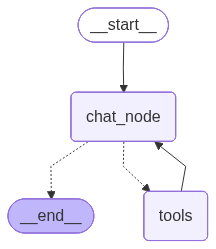

In [34]:
chatbot

In [35]:
# initial_state = {
#     'messages': [HumanMessage(content="What is the capital of India?")]
# }
# chatbot.invoke(initial_state)['messages'][-1].content

In [36]:
# ── Thread Selection ────────────────────────────────────────────────────
# List existing threads from the SQLite checkpoint so users can resume
# a previous conversation. Each thread_id is a UUID string.

import uuid

# --- Thread selection ---
# The 'checkpoints' table is created by SqliteSaver on the first save.
# On a fresh database it won't exist yet, so we catch that error and
# treat it the same as having no previous threads.
try:
    existing = conn.execute(
        "SELECT DISTINCT thread_id FROM checkpoints ORDER BY thread_id"
    ).fetchall()
except Exception:
    existing = []

if existing:
    print('Existing threads:')
    for i, (tid,) in enumerate(existing, 1):
        print(f'  [{i}] {tid}')
    print(f'  [n] Start a new thread')
    choice = input('Select a thread number or "n" for new: ').strip().lower()
    if choice == 'n' or not choice.isdigit():
        thread_id = str(uuid.uuid4())
        print(f'New thread created: {thread_id}')
    else:
        idx = int(choice) - 1
        thread_id = existing[idx][0]
        print(f'Resuming thread: {thread_id}')
else:
    thread_id = str(uuid.uuid4())
    print(f'No existing threads found. New thread created: {thread_id}')

Existing threads:
  [1] 07193a44-42d2-44d8-a435-ab2a44d07ffb
  [n] Start a new thread
New thread created: df7f51c0-31c0-49fe-8e75-7f5b8dcddb6d


In [38]:
# --- Chat loop ---
while True:

    user_query = input('Ask your query: ')

    print('User: ', user_query)

    if not user_query.strip():
        print('Please enter a non-empty query.')
        continue

    if user_query.strip().lower() in ['exit', 'bye', 'fuck you', 'quit']:
        print('AI: Hope you got answers')
        break

    config = {
        'configurable': {
            'thread_id': thread_id,
            # [NEW] metadata is attached to every LangSmith trace for this run,
            # making it easy to filter traces by thread in the observability dashboard.
            'metadata': {
                'thread_id': thread_id
            },
            # [NEW] run_name labels each invocation in LangSmith so you can
            # tell individual chat turns apart at a glance.
            'run_name': 'chat_turn'
        }
    }

    for message_chunk, metadata in chatbot.stream(
        { 'messages' : [HumanMessage(content=user_query)] },
        config=config,
        stream_mode='messages'
    ): 
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)
    print()

User:  what is decision tree?
A **decision tree** is a **supervised machine learning algorithm** used for **classification** and **regression** tasks. It works by splitting the data into subsets based on **feature values**, creating a tree-like structure of decisions (branches) leading to an outcome (leaf nodes).

### **Key Components of a Decision Tree:**
1. **Root Node** – The topmost decision node (first split).
2. **Internal Nodes** – Decision points based on features.
3. **Branches (Edges)** – Possible outcomes of a decision.
4. **Leaf Nodes** – Final predictions (class labels for classification or continuous values for regression).

### **How It Works:**
1. **Feature Selection:** At each node, the algorithm selects the best feature to split the data (using criteria like **Gini impurity, entropy, or variance reduction**).
2. **Splitting:** The data is divided into subsets based on feature thresholds.
3. **Recursion:** The process repeats for each subset until a stopping condition 